In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import zarr
from diffusion_policy.common.replay_buffer import ReplayBuffer
from omegaconf import OmegaConf
from diffusion_policy.codecs.imagecodecs_numcodecs import register_codecs
from umi.common.pose_util import (
    pose_to_mat, mat_to_pose, 
    mat_to_pose10d, pose10d_to_mat)
from diffusion_policy.common.pose_repr_util import convert_pose_mat_rep

from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from scipy.spatial.transform import Rotation as R

In [2]:
OmegaConf.register_new_resolver("eval", eval, replace=True)
register_codecs()

In [3]:
def plot_traj(file_path):
    trajectory_data = pd.read_csv(file_path)
    # Extract relevant data
    x = trajectory_data['x']
    y = trajectory_data['y']
    z = trajectory_data['z']
    qx = trajectory_data['q_x']
    qy = trajectory_data['q_y']
    qz = trajectory_data['q_z']
    qw = trajectory_data['q_w']
    
    timestamps = trajectory_data['timestamp']
    color_intensity_time = (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())
    
    # Create the 3D plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x, y, z, c=color_intensity_time, cmap='cividis', s=5)
    
    # Label axes
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    
    # Add color bar for reference
    
    plt.show()

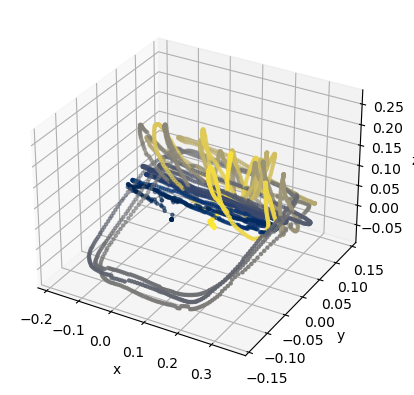

In [10]:
file_path0410 = '/home/soochul/GoPro_20250410/demos/mapping/mapping_camera_trajectory.csv'
plot_traj(file_path0410)

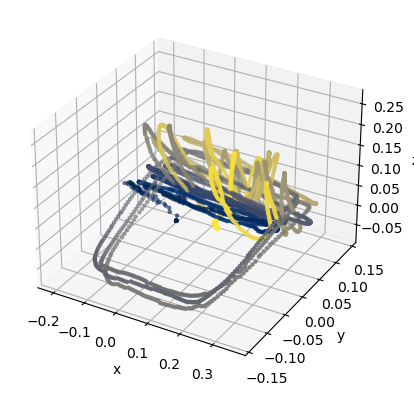

In [11]:
file_path0508 = '/home/soochul/GoPro_20250508/demos/mapping/mapping_camera_trajectory.csv'
plot_traj(file_path0508)

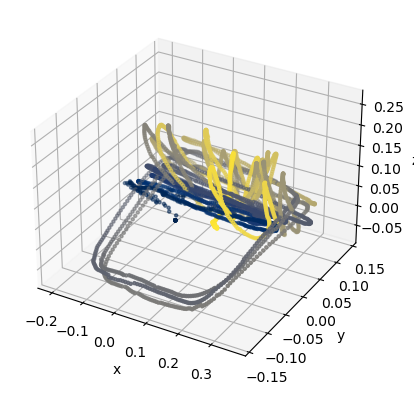

In [12]:
file_path0509 = '/home/soochul/GoPro_20250509/demos/mapping/mapping_camera_trajectory.csv'
plot_traj(file_path0509)

In [24]:
def plot_traj(file_path):
    trajectory_data = pd.read_csv(file_path)
    # Extract relevant data
    x = trajectory_data['x']
    y = trajectory_data['y']
    z = trajectory_data['z']
    qx = trajectory_data['q_x']
    qy = trajectory_data['q_y']
    qz = trajectory_data['q_z']
    qw = trajectory_data['q_w']
    
    timestamps = trajectory_data['timestamp']
    color_intensity_time = (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())
    
    # Create the 3D plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x, y, z, c=color_intensity_time, cmap='cividis', s=5)
    
    # Label axes
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    
    # Add color bar for reference
    
    plt.show()

def extract_traj(file_path):
    trajectory_data = pd.read_csv(file_path)
    # Extract relevant data
    x = trajectory_data['x']
    y = trajectory_data['y']
    z = trajectory_data['z']
    qx = trajectory_data['q_x']
    qy = trajectory_data['q_y']
    qz = trajectory_data['q_z']
    qw = trajectory_data['q_w']
    
    timestamps = trajectory_data['timestamp']

    poses = []
    last_valid_quat = None
    
    for i in range(len(timestamps)):
        quat = np.array([qx[i], qy[i], qz[i], qw[i]])
        if np.linalg.norm(quat) < 1e-6:
            # print(f"[Warning] Zero quaternion at index {i}, timestamp {timestamps[i]}")
            if last_valid_quat is not None:
                quat = last_valid_quat  # Use last valid quaternion
            else:
                quat = np.array([0.0, 0.0, 0.0, 1.0])  # Identity quaternion
        
        else:
            last_valid_quat = quat / np.linalg.norm(quat)  # Normalize quaternion

        T = np.eye(4)
        T[:3, 3] = [x[i], y[i], z[i]]
        R_mat = R.from_quat(quat).as_matrix()
        T[:3, :3] = R_mat
        poses.append(T)
    
    return poses, timestamps

def similarity_check(original_pose_path, other_pose_path):
    original_traj, original_timestamps = extract_traj(original_pose_path)
    other_traj, other_timestamps = extract_traj(other_pose_path)

    assert len(original_traj) == len(other_traj), "Trajectory length mismatch!"

    pos_errors = []
    rot_errors = []

    for orig_pose, other_pose in zip(original_traj, other_traj):
        diff = np.linalg.inv(orig_pose) @ other_pose

        # Position error
        p_diff = diff[:3, 3]
        pos_err = np.linalg.norm(p_diff)

        # Rotation error (angle axis)
        R_diff = diff[:3, :3]
        trace_val = np.trace(R_diff)
        cos_angle = (trace_val - 1.0) / 2.0
        cos_angle = np.clip(cos_angle, -1.0, 1.0)  # Safe clipping
        rot_err = np.arccos(cos_angle)

        pos_errors.append(pos_err)
        rot_errors.append(rot_err)

    # You can return the arrays, or mean, median etc.
    mean_pos_err = np.mean(pos_errors)
    mean_rot_err = np.mean(rot_errors)

    return mean_pos_err, mean_rot_err, pos_errors, rot_errors

In [25]:
mean_pos_err, mean_rot_err, pos_errors, rot_errors = similarity_check(file_path0410, file_path0508)

print(f"Mean Position Error: {mean_pos_err:.4f} m, Mean Rotation Error: {np.degrees(mean_rot_err):.4f} degrees")

Mean Position Error: 0.0024 m, Mean Rotation Error: 0.0994 degrees


In [26]:
mean_pos_err, mean_rot_err, pos_errors, rot_errors = similarity_check(file_path0410, file_path0509)

print(f"Mean Position Error: {mean_pos_err:.4f} m, Mean Rotation Error: {np.degrees(mean_rot_err):.4f} degrees")

Mean Position Error: 0.0023 m, Mean Rotation Error: 0.0986 degrees


In [27]:
mean_pos_err, mean_rot_err, pos_errors, rot_errors = similarity_check(file_path0508, file_path0509)

print(f"Mean Position Error: {mean_pos_err:.4f} m, Mean Rotation Error: {np.degrees(mean_rot_err):.4f} degrees")

Mean Position Error: 0.0021 m, Mean Rotation Error: 0.0944 degrees
